In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Setup ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(f"Using device: {device}")

# --- 1. Environment Parameters ---
K = 300  # Number of devices
r_cvge = 400 # BS coverage - 400m
P = 20 # Maximum symbol power [dBm]
sigma_z2 = -50 # Effective noise power [dBm]
gamma = -10 # Coefficient for power scaling [dB]

# Linear Scale Conversions
P_mW = 10 ** (P / 10.0)
sigma_z2_mW = 10 ** (sigma_z2 / 10.0)
gamma_lin = 10 ** (gamma / 10.0)

F = 1024 # Number of sub-channels
alpha = 4 # Path loss exponent
M_0 = 200 # BS dataset size [samples]

lr = 0.05 # Learning rate
batch_size = 10 # Mini-batch size in local training
epoch = 3 # Local training epoch
D = 582026 # Number of DNN parameters

T_th = 0.5 * (r_cvge ** (-alpha)) # Truncation threshold

# --- 2. Model Architecture ---
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

# --- 3. Data Preparation ---
def get_dataset(K=300, M_0=200, mean_size=200):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    all_indices = np.arange(len(train_dataset))
    np.random.shuffle(all_indices)

    bs_indices = all_indices[:M_0]
    bs_dataset = Subset(train_dataset, bs_indices)

    remaining_indices = all_indices[M_0:]
    targets = train_dataset.targets.numpy()

    class_indices = {i: [] for i in range(10)}
    for idx in remaining_indices:
        class_indices[targets[idx]].append(idx)

    for i in range(10): np.random.shuffle(class_indices[i])

    client_datasets = []
    for k in range(K):
        N_k = max(10, np.random.poisson(mean_size))
        selected_classes = np.random.choice(10, 3, replace=False)

        samples_per_class = [N_k // 3] * 3
        for i in range(N_k % 3): samples_per_class[i] += 1

        client_indices = []
        for c, num_samples in zip(selected_classes, samples_per_class):
            if len(class_indices[c]) >= num_samples:
                client_indices.extend(class_indices[c][:num_samples])
                class_indices[c] = class_indices[c][num_samples:]
            else:
                client_indices.extend(class_indices[c])
                deficit = num_samples - len(class_indices[c])
                class_indices[c] = []
                all_c_indices = [idx for idx in remaining_indices if targets[idx] == c]
                client_indices.extend(np.random.choice(all_c_indices, deficit, replace=True))

        np.random.shuffle(client_indices)
        client_datasets.append(Subset(train_dataset, client_indices))

    return bs_dataset, client_datasets, test_dataset

# --- 4. Local Training Functions ---
def local_update(global_model, local_dataset, lr=0.05, batch_size=10, epochs=3):
    local_model = CNNModel().to(device)
    local_model.load_state_dict(global_model.state_dict())
    local_model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(local_model.parameters(), lr=lr)
    train_loader = DataLoader(local_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = local_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return local_model.state_dict()

def get_flattened_delta(global_state_dict, local_state_dict):
    delta_list = []
    for key in global_state_dict.keys():
        diff = local_state_dict[key] - global_state_dict[key]
        delta_list.append(diff.view(-1))
    return torch.cat(delta_list)

def apply_flattened_update(global_model, aggregated_delta_flat):
    new_state_dict = global_model.state_dict()
    current_index = 0
    for key in new_state_dict.keys():
        param_shape = new_state_dict[key].shape
        num_params = new_state_dict[key].numel()
        layer_delta = aggregated_delta_flat[current_index : current_index + num_params].view(param_shape)
        new_state_dict[key] += layer_delta
        current_index += num_params
    global_model.load_state_dict(new_state_dict)

# --- 5. Power Optimization (Algorithm 2) ---
def optimize_power_allocation(u_arg, delta_arg, P_arg, F, epsilon=1e-5):
    rho = delta_arg ** 2
    c_up = torch.sqrt((F / P_arg) * torch.max(rho * u_arg)).item()
    c_low = 0.0

    if torch.sum(u_arg * rho) <= P_arg:
        return u_arg * rho

    max_iters = 100
    for _ in range(max_iters):
        c = (c_up + c_low) / 2.0
        scale_factor = (1.0 + c * u_arg)
        p_out = (u_arg * rho) / (scale_factor ** 2)
        diff = P_arg - torch.sum(p_out).item()

        if diff > 0: c_up = c
        else: c_low = c

        if abs(diff) <= epsilon: break
    return p_out

# --- 6. Main OTA Federated Learning Loop (Algorithm 3) ---
def evaluate_model(model, test_dataset):
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return correct / len(test_dataset)

def run_ota_federated_learning(bs_dataset, client_datasets, test_dataset, K, D, F,P_mW = P_mW, r_k_dist = None, num_rounds=100):
    global_model = CNNModel().to(device)

    Nt_list = []
    acc_list = []
    M_0 = len(bs_dataset)
    M_k = [len(d) for d in client_datasets]
    M_total = M_0 + sum(M_k)

    w_0 = M_0 / M_total
    w_k = [m / M_total for m in M_k]

    N = int(np.ceil(D / F))
    pad_size = (N * F) - D
    if r_k_dist is None:
        r_k_dist = np.clip(550 * np.sqrt(np.random.rand(K)), 10.0, 550)
    print(f"Aggregating {K} devices over the air...")

    for t in range(num_rounds):
        # 1. Base Station Update
        theta_t0_dict = local_update(global_model, bs_dataset, lr, batch_size, epoch)
        delta_t0 = get_flattened_delta(global_model.state_dict(), theta_t0_dict)

        apply_flattened_update(global_model, w_0 * delta_t0)
        rho_ref_t = (torch.norm(delta_t0) ** 2) / D

        y_t = torch.zeros((N, F), dtype=torch.complex64).to(device)

        # 2. Edge Device Updates
        for k in range(K):
            theta_tk_dict = local_update(global_model, client_datasets[k], lr, batch_size, epoch)
            delta_tk = get_flattened_delta(global_model.state_dict(), theta_tk_dict)

            padded_delta_tk = torch.nn.functional.pad(delta_tk, (0, pad_size), "constant", 0.0)
            delta_tk_N = padded_delta_tk.view(N, F)

            for n in range(N):
                variance = r_k_dist[k] ** (-alpha)
                std_dev = np.sqrt(variance / 2.0)

                h_tk_n = torch.complex(torch.normal(0.0, std_dev, size=(F,)),
                                       torch.normal(0.0, std_dev, size=(F,))).to(device)

                g_tk_n = 1.0 / (torch.abs(h_tk_n) ** 2)
                u_tk_n = (w_k[k] ** 2) * ((gamma_lin * sigma_z2_mW) / rho_ref_t) * g_tk_n

                p_tk_n = optimize_power_allocation(u_tk_n, delta_tk_N[n], P_mW, F)

                phase_inversion = torch.conj(h_tk_n) / torch.abs(h_tk_n)
                x_tk_n = phase_inversion * torch.sign(delta_tk_N[n]) * torch.sqrt(p_tk_n)

                y_t[n] += h_tk_n * x_tk_n

        # 3. Base Station Aggregation
        noise_std = np.sqrt(sigma_z2_mW / 2.0)
        z_t = torch.complex(torch.normal(0.0, noise_std, size=(N, F)),
                            torch.normal(0.0, noise_std, size=(N, F))).to(device)

        y_t_noisy = y_t + z_t
        delta_sum_hat = torch.sqrt(rho_ref_t / (gamma_lin * sigma_z2_mW)) * y_t_noisy.real

        delta_sum_flat = delta_sum_hat.view(-1)[:D]
        apply_flattened_update(global_model, delta_sum_flat)

        acc = evaluate_model(global_model, test_dataset)
        print(f"Round {t+1} Completed. Test Accuracy: {acc * 100:.2f}%")

        current_Nt = (t + 1) * N
        Nt_list.append(current_Nt)
        acc_list.append(acc)
    return global_model, Nt_list, acc_list

Using device: cpu


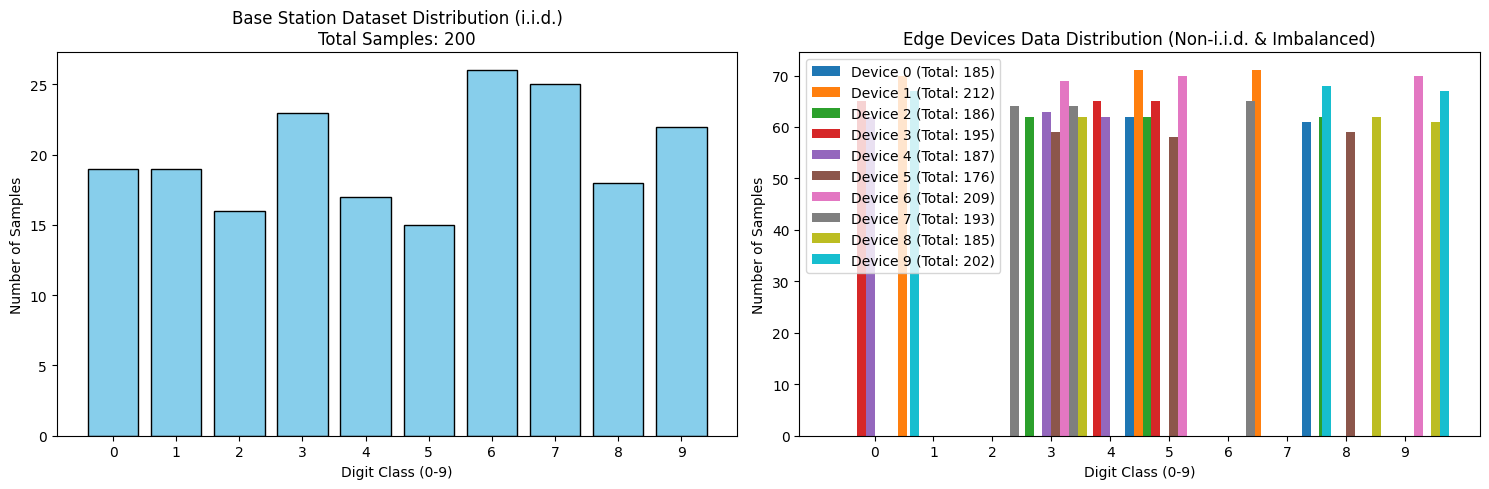

In [5]:
def plot_data_distribution(bs_dataset, client_datasets, num_clients_to_show=5):
    """
    Plots the label distribution for the Base Station and a few selected clients.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- 1. BS Dataset Distribution ---
    # Extract labels using the indices stored in the Subset
    bs_labels = [bs_dataset.dataset.targets[idx].item() for idx in bs_dataset.indices]
    bs_counts = np.bincount(bs_labels, minlength=10)
    
    axes[0].bar(range(10), bs_counts, color='skyblue', edgecolor='black')
    axes[0].set_title('Base Station Dataset Distribution (i.i.d.)\nTotal Samples: {}'.format(sum(bs_counts)))
    axes[0].set_xlabel('Digit Class (0-9)')
    axes[0].set_ylabel('Number of Samples')
    axes[0].set_xticks(range(10))
    
    # --- 2. Client Dataset Distribution (First few clients) ---
    width = 0.15 # Width of the bars for grouped charting
    x = np.arange(10)
    
    for i in range(num_clients_to_show):
        client_labels = [client_datasets[i].dataset.targets[idx].item() for idx in client_datasets[i].indices]
        client_counts = np.bincount(client_labels, minlength=10)
        
        # Offset each client's bars so they group nicely side-by-side
        axes[1].bar(x + (i - num_clients_to_show/2) * width + width/2, 
                    client_counts, 
                    width=width, 
                    label=f'Device {i} (Total: {sum(client_counts)})')
        
    axes[1].set_title(f'Edge Devices Data Distribution (Non-i.i.d. & Imbalanced)')
    axes[1].set_xlabel('Digit Class (0-9)')
    axes[1].set_ylabel('Number of Samples')
    axes[1].set_xticks(range(10))
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# --- Run the visualization ---
# Generate the data
bs_dataset, client_datasets, test_dataset = get_dataset(K=K, M_0=M_0)

# Plot it
plot_data_distribution(bs_dataset, client_datasets, num_clients_to_show=10)


STARTING SIMULATION FOR r_cvge = 50m
Devices actively in range: 3 / 300
Aggregating 3 devices over the air...
Round 1 Completed. Test Accuracy: 65.14%
Round 2 Completed. Test Accuracy: 72.70%
Round 3 Completed. Test Accuracy: 77.66%
Round 4 Completed. Test Accuracy: 81.73%
Round 5 Completed. Test Accuracy: 86.17%
Round 6 Completed. Test Accuracy: 87.90%
Round 7 Completed. Test Accuracy: 89.87%
Round 8 Completed. Test Accuracy: 90.41%
Round 9 Completed. Test Accuracy: 91.19%
Round 10 Completed. Test Accuracy: 91.49%
Round 11 Completed. Test Accuracy: 91.58%
Round 12 Completed. Test Accuracy: 92.01%
Round 13 Completed. Test Accuracy: 92.03%
Round 14 Completed. Test Accuracy: 92.18%
Round 15 Completed. Test Accuracy: 92.25%
Round 16 Completed. Test Accuracy: 92.33%
Round 17 Completed. Test Accuracy: 92.32%
Round 18 Completed. Test Accuracy: 92.58%
Round 19 Completed. Test Accuracy: 92.56%
Round 20 Completed. Test Accuracy: 92.68%
Round 21 Completed. Test Accuracy: 92.83%
Round 22 Complet

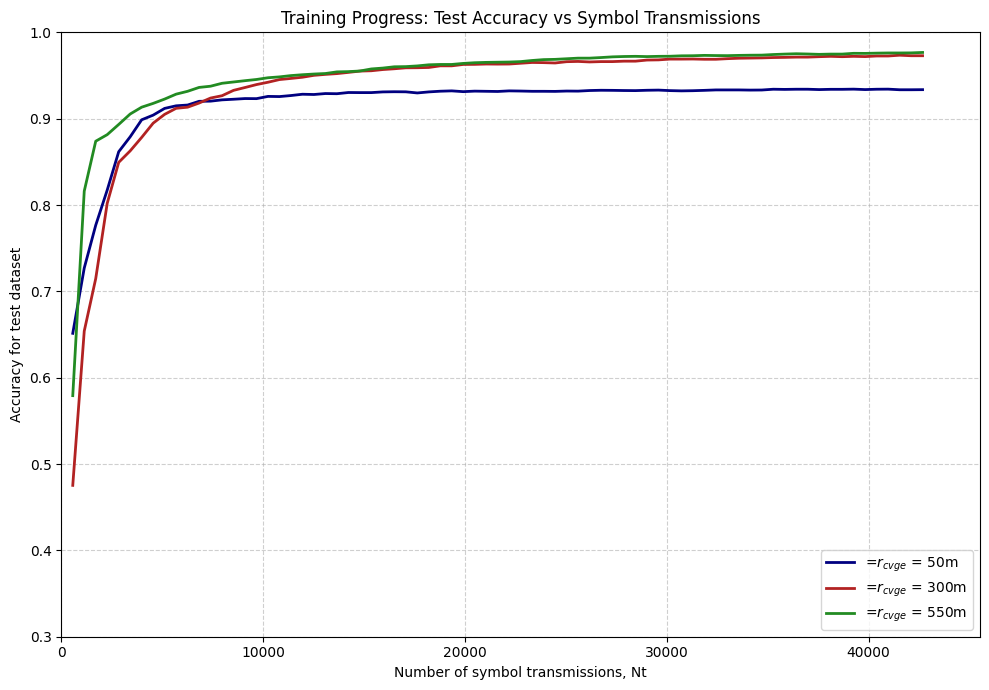

In [6]:
# --- Fig 2 Simulation Script (Corrected BS Effective Zone) ---
if __name__ == "__main__":
    
    # The 3 different effective coverage radii you want to test
    r_cvge_values = [50, 300, 550]
    
    colors = {50: 'navy', 300: 'firebrick', 550: 'forestgreen'}
    results = {}
    N = int(np.ceil(D / F))

    # Distribute all 300 devices within 550m
    max_physical_radius = 550.0
    global_r_k_dist = np.clip(max_physical_radius * np.sqrt(np.random.rand(K)), 10.0, max_physical_radius)
    bs_data, global_client_data, test_data = get_dataset(K=K, M_0=M_0)

    # --- Run the 3 Simulations ---
    for radius in r_cvge_values:
        print(f"\n{'='*50}")
        print(f"STARTING SIMULATION FOR r_cvge = {radius}m")
        
        # 3. THE FILTER: Find which devices are physically inside the BS coverage zone
        active_indices = [k for k in range(K) if global_r_k_dist[k] <= radius]
        K_active = len(active_indices)
        
        print(f"Devices actively in range: {K_active} / {K}")
        print(f"{'='*50}")
        
        # If the radius is so small that nobody is in range, we skip to avoid crashing
        if K_active == 0:
            print("No devices in range! Skipping this radius...")
            continue
            
        # 4. Extract only the datasets and distances for the active devices
        active_client_data = [global_client_data[i] for i in active_indices]
        active_r_k_dist = global_r_k_dist[active_indices]
        
        # 5. Run simulation with K_active devices
        _, Nt_list, acc_list = run_ota_federated_learning(
            bs_data, active_client_data, test_data, 
            K=K_active, D=D, F=F, 
            P_mW=P_mW, 
            r_k_dist=active_r_k_dist, 
            num_rounds=75
        )
        
        results[radius] = {'Nt': Nt_list, 'acc': acc_list}

    # --- Plotting ---
    plt.figure(figsize=(10, 7))
    
    for radius in sorted(results.keys()): 
        plt.plot(results[radius]['Nt'], results[radius]['acc'], 
                 label=f'$r_{{cvge}}$ = {radius}m', 
                 color=colors[radius], linewidth=2)
        
    plt.title('Training Progress: Test Accuracy vs Symbol Transmissions')
    plt.xlabel('Number of symbol transmissions, Nt')
    plt.ylabel('Accuracy for test dataset')
    
    plt.ylim(0.3, 1.0) 
    max_Nt = max(results[list(results.keys())[0]]['Nt']) 
    plt.xlim(0, max_Nt + (N * 5))
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()